In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
class LassoRegression:
    def __init__(self, alpha=1.0, learning_rate=0.001, epochs=2000):
        self.alpha = alpha
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Warm start: keep weights from previous alpha for faster convergence
        if self.weights is None:
            self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for _ in range(self.epochs):
            y_pred = X.dot(self.weights) + self.bias
            dw = (-1 / n_samples) * X.T.dot(y - y_pred) + self.alpha * np.sign(self.weights)
            db = (-1 / n_samples) * np.sum(y - y_pred)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

In [6]:
if __name__ == "__main__":
    # 1. Load Data
    df = pd.read_csv('laptop_prices.csv')
    csv_columns = ['cpu_cores', 'ram_gb', 'gpu_memory_gb', 'sticker_count']
    X_data = df[csv_columns].values 
    y_data = df['price_usd'].values
    feature_names = ['CPU', 'RAM', 'GPU', 'Stickers']

    # 2. Test different values of alpha
    # Lasso requires a different alpha scale than Ridge to see the effect clearly
    alphas = np.linspace(0.1, 500, 50)
    weights_history = []
    
    # Initialize the model once outside the loop to use "warm starts"
    # This makes gradient descent MUCH faster across a path
    model = LassoRegression(learning_rate=0.0005, epochs=3000)

    for a in alphas:
        model.alpha = a
        model.fit(X_data, y_data)
        # We must copy the array, otherwise it just references the final state
        weights_history.append(np.copy(model.weights)) 
        
    weights_history = np.array(weights_history)

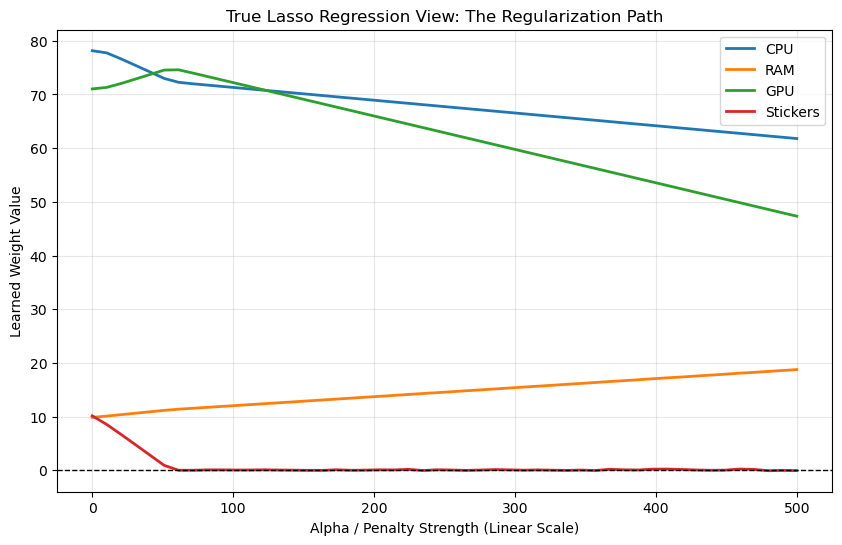

In [7]:
    plt.figure(figsize=(10, 6))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i in range(len(feature_names)):
        plt.plot(alphas, weights_history[:, i], label=feature_names[i], color=colors[i], linewidth=2)

    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.title('True Lasso Regression View: The Regularization Path')
    plt.xlabel('Alpha / Penalty Strength (Linear Scale)')
    plt.ylabel('Learned Weight Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()